# Sentence embedding clusters by IR section

This notebook compares one skill document with one deterministic BABILong 8k prompt. It calls Alexandria's `represent()` and works only with sentence embeddings stored in the resulting IR. UMAP produces a clustering space and a two-dimensional view; HDBSCAN assigns cluster labels. In the main view, color always means the sentence's deepest containing IR section.

In [1]:
import os
import sys
from collections import Counter
from importlib import import_module
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from dotenv import load_dotenv
from hdbscan import HDBSCAN
from umap import UMAP

from alexandria.ir.document import Document, Section, Sentence
from alexandria.ops.features.represent import represent


def find_repo_root() -> Path:
    for candidate in (Path.cwd(), *Path.cwd().parents):
        if (candidate / "pyproject.toml").is_file() and (candidate / "src/alexandria").is_dir():
            return candidate
    raise RuntimeError("Run this notebook from the Alexandria checkout.")


REPO_ROOT = find_repo_root()
sys.path.insert(0, str(REPO_ROOT))
load_cases = import_module("benchmarks.babilong_8k.cases").load_cases
load_dotenv(REPO_ROOT / ".env")
RANDOM_SEED = 42
print(f"repository: {REPO_ROOT.name}")

repository: alexandria-embedding-clusters


## Load the two inputs

`load_cases(n=1, seed=42)` selects one task-balanced benchmark case reproducibly. The downloaded benchmark data is intentionally git-ignored; run the downloader shown in `notebooks/README.md` before this cell.

In [2]:
default_skill_path = (
    REPO_ROOT.parent / "skill-corpus/corpus/obra__superpowers/skills/subagent-driven-development/SKILL.md"
)
skill_path = Path(os.environ.get("ALEXANDRIA_SKILL_PATH", default_skill_path)).expanduser()
data_dir = REPO_ROOT / "data/babilong/8k"

if not skill_path.is_file():
    raise FileNotFoundError(f"Skill file not found at {skill_path}. Set ALEXANDRIA_SKILL_PATH to its absolute path.")
if not (data_dir / "qa1.json").is_file():
    raise FileNotFoundError("BABILong data is missing. Run `uv run python -m scripts.download_babilong_8k_data`.")

skill_text = skill_path.read_text(encoding="utf-8")
benchmark_case = load_cases(n=1, seed=RANDOM_SEED, data_dir=data_dir)[0]
inputs = {
    "skill": skill_text,
    f"babilong {benchmark_case.key}": benchmark_case.prompt,
}

print(f"skill: {Path(*skill_path.parts[-4:])}")
print(f"benchmark case: {benchmark_case.key} ({benchmark_case.task})")
print({name: len(text) for name, text in inputs.items()})

skill: obra__superpowers/skills/subagent-driven-development/SKILL.md
benchmark case: qa1:42 (qa1)
{'skill': 21540, 'babilong qa1:42': 31424}


## Build Alexandria IR

No embedding client is created in the notebook. Omitting `embedder` delegates to Alexandria's default `text-embedding-3-small` implementation, and the following analysis reads each vector from `Document.sentences`.

In [3]:
documents = {name: represent(text) for name, text in inputs.items()}
for name, document in documents.items():
    print(
        f"{name}: {len(document.sentences)} sentences, "
        f"{len(document.sections)} root sections, model={document.embedding_model}"
    )

skill: 396 sentences, 2 root sections, model=text-embedding-3-small
babilong qa1:42: 686 sentences, 6 root sections, model=text-embedding-3-small


## Preserve the sentence-to-section relationship

A sentence inherits the deepest `Section` that directly contains it. The index path disambiguates repeated XML tags such as `<example>`.

In [4]:
def sentence_rows(document: Document, source: str) -> list[dict[str, object]]:
    rows: list[dict[str, object]] = []

    def visit(section: Section, path: tuple[int, ...]) -> None:
        section_name = section.header.strip() or section.kind.value
        path_label = ".".join(str(part) for part in path)
        section_label = f"{source} / {section_name} [{path_label}]"
        nested_index = 0
        for child in section.children:
            if isinstance(child, Sentence):
                rows.append(
                    {
                        "source": source,
                        "section": section_label,
                        "sentence_id": str(child.id),
                        "text": child.text.strip(),
                        "optimizable": child.optimizable,
                        "embedding": child.embedding,
                    }
                )
            else:
                nested_index += 1
                visit(child, (*path, nested_index))

    for root_index, section in enumerate(document.sections, start=1):
        visit(section, (root_index,))
    return rows


rows_by_source = {source: sentence_rows(document, source) for source, document in documents.items()}
for source, source_rows in rows_by_source.items():
    section_counts = Counter(str(row["section"]) for row in source_rows)
    dimensions = np.asarray(source_rows[0]["embedding"]).shape[0]
    print(f"{source}: embedding matrix=({len(source_rows)}, {dimensions}), sections={len(section_counts)}")
    for section, count in section_counts.items():
        print(f"{count:>4}  {section}")

skill: embedding matrix=(396, 1536), sections=16
   4  skill / plain [1]
  14  skill / Subagent-Driven Development [2]
  33  skill / When to Use [2.1]
  44  skill / The Process [2.2]
  11  skill / Pre-Flight Plan Review [2.3]
  28  skill / Model Selection [2.4]
  18  skill / Handling Implementer Status [2.5]
   8  skill / Handling Reviewer ⚠️ Items [2.6]
  65  skill / Constructing Reviewer Prompts [2.7]
  29  skill / File Handoffs [2.8]
  21  skill / Durable Progress [2.9]
   4  skill / Prompt Templates [2.10]
  47  skill / Example Workflow [2.11]
  26  skill / Advantages [2.12]
  34  skill / Red Flags [2.13]
  10  skill / Integration [2.14]
babilong qa1:42: embedding matrix=(686, 1536), sections=6
   3  babilong qa1:42 / plain [1]
   7  babilong qa1:42 / example [2]
   8  babilong qa1:42 / example [3]
   2  babilong qa1:42 / plain [4]
 665  babilong qa1:42 / context [5]
   1  babilong qa1:42 / plain [6]


## UMAP + HDBSCAN

Each input is reduced and clustered independently so that the large difference between the two source documents does not dominate their local structure. For each input, clustering uses a 10-dimensional UMAP space (`cosine`, `min_dist=0`), while a separate two-dimensional UMAP is used only for plotting. HDBSCAN uses leaf selection to expose fine local groups. Coordinates and cluster numbers are local to one input and must not be compared across the two figures.

In [5]:
analyses: dict[str, dict[str, object]] = {}
for source, source_rows in rows_by_source.items():
    embeddings = np.stack([row["embedding"] for row in source_rows])
    n_neighbors = min(30, len(source_rows) - 1)
    cluster_space = UMAP(
        n_components=10,
        n_neighbors=n_neighbors,
        min_dist=0.0,
        metric="cosine",
        random_state=RANDOM_SEED,
        n_jobs=1,
    ).fit_transform(embeddings)
    plot_space = UMAP(
        n_components=2,
        n_neighbors=n_neighbors,
        min_dist=0.1,
        metric="cosine",
        random_state=RANDOM_SEED,
        n_jobs=1,
    ).fit_transform(embeddings)

    min_cluster_size = max(10, len(source_rows) // 30)
    cluster_labels = HDBSCAN(
        min_cluster_size=min_cluster_size,
        min_samples=3,
        metric="euclidean",
        cluster_selection_method="leaf",
    ).fit_predict(cluster_space)
    cluster_counts = Counter(int(label) for label in cluster_labels)
    analyses[source] = {
        "rows": source_rows,
        "plot_space": plot_space,
        "cluster_labels": cluster_labels,
        "cluster_counts": cluster_counts,
        "min_cluster_size": min_cluster_size,
    }
    cluster_total = len(cluster_counts) - (-1 in cluster_counts)
    print(
        f"{source}: clusters={cluster_total}, noise={cluster_counts.get(-1, 0)}, min_cluster_size={min_cluster_size}"
    )

skill: clusters=14, noise=106, min_cluster_size=13


babilong qa1:42: clusters=9, noise=258, min_cluster_size=22


In [6]:
for source, analysis in analyses.items():
    source_rows = analysis["rows"]
    cluster_labels = analysis["cluster_labels"]
    cluster_counts = analysis["cluster_counts"]
    print(f"\n{source}")
    for label in sorted(cluster_counts):
        mask = cluster_labels == label
        members = [source_rows[index] for index in np.flatnonzero(mask)]
        dominant_section, dominant_count = Counter(str(member["section"]) for member in members).most_common(1)[0]
        name = "noise" if label == -1 else f"cluster {label}"
        print(f"{name:>10}: n={len(members):>4}, dominant={dominant_count / len(members):.1%} {dominant_section}")


skill
     noise: n= 106, dominant=17.0% skill / File Handoffs [2.8]
 cluster 0: n=  23, dominant=39.1% skill / When to Use [2.1]
 cluster 1: n=  18, dominant=50.0% skill / Example Workflow [2.11]
 cluster 2: n=  17, dominant=23.5% skill / Durable Progress [2.9]
 cluster 3: n=  20, dominant=90.0% skill / Model Selection [2.4]
 cluster 4: n=  17, dominant=70.6% skill / Constructing Reviewer Prompts [2.7]
 cluster 5: n=  27, dominant=22.2% skill / Advantages [2.12]
 cluster 6: n=  13, dominant=61.5% skill / When to Use [2.1]
 cluster 7: n=  22, dominant=40.9% skill / Durable Progress [2.9]
 cluster 8: n=  21, dominant=23.8% skill / Red Flags [2.13]
 cluster 9: n=  30, dominant=36.7% skill / The Process [2.2]
cluster 10: n=  18, dominant=38.9% skill / Constructing Reviewer Prompts [2.7]
cluster 11: n=  18, dominant=55.6% skill / Constructing Reviewer Prompts [2.7]
cluster 12: n=  18, dominant=33.3% skill / Example Workflow [2.11]
cluster 13: n=  28, dominant=28.6% skill / Constructing Re

## Separate two-dimensional views for each input

The skill and BABILong prompt are rendered as separate figures from independent UMAP/HDBSCAN fits. Within each figure, panels A and B contain exactly the same sentences at exactly the same coordinates; only the meaning of color changes. Panel A uses known IR section membership, panel B uses the unsupervised HDBSCAN result, and panel C directly compares their distributions. Gray points and the `noise` column are sentences HDBSCAN deliberately leaves unassigned. Coordinates and cluster IDs have no cross-figure meaning.

wrote notebooks/outputs/skill_section_embedding_clusters.png


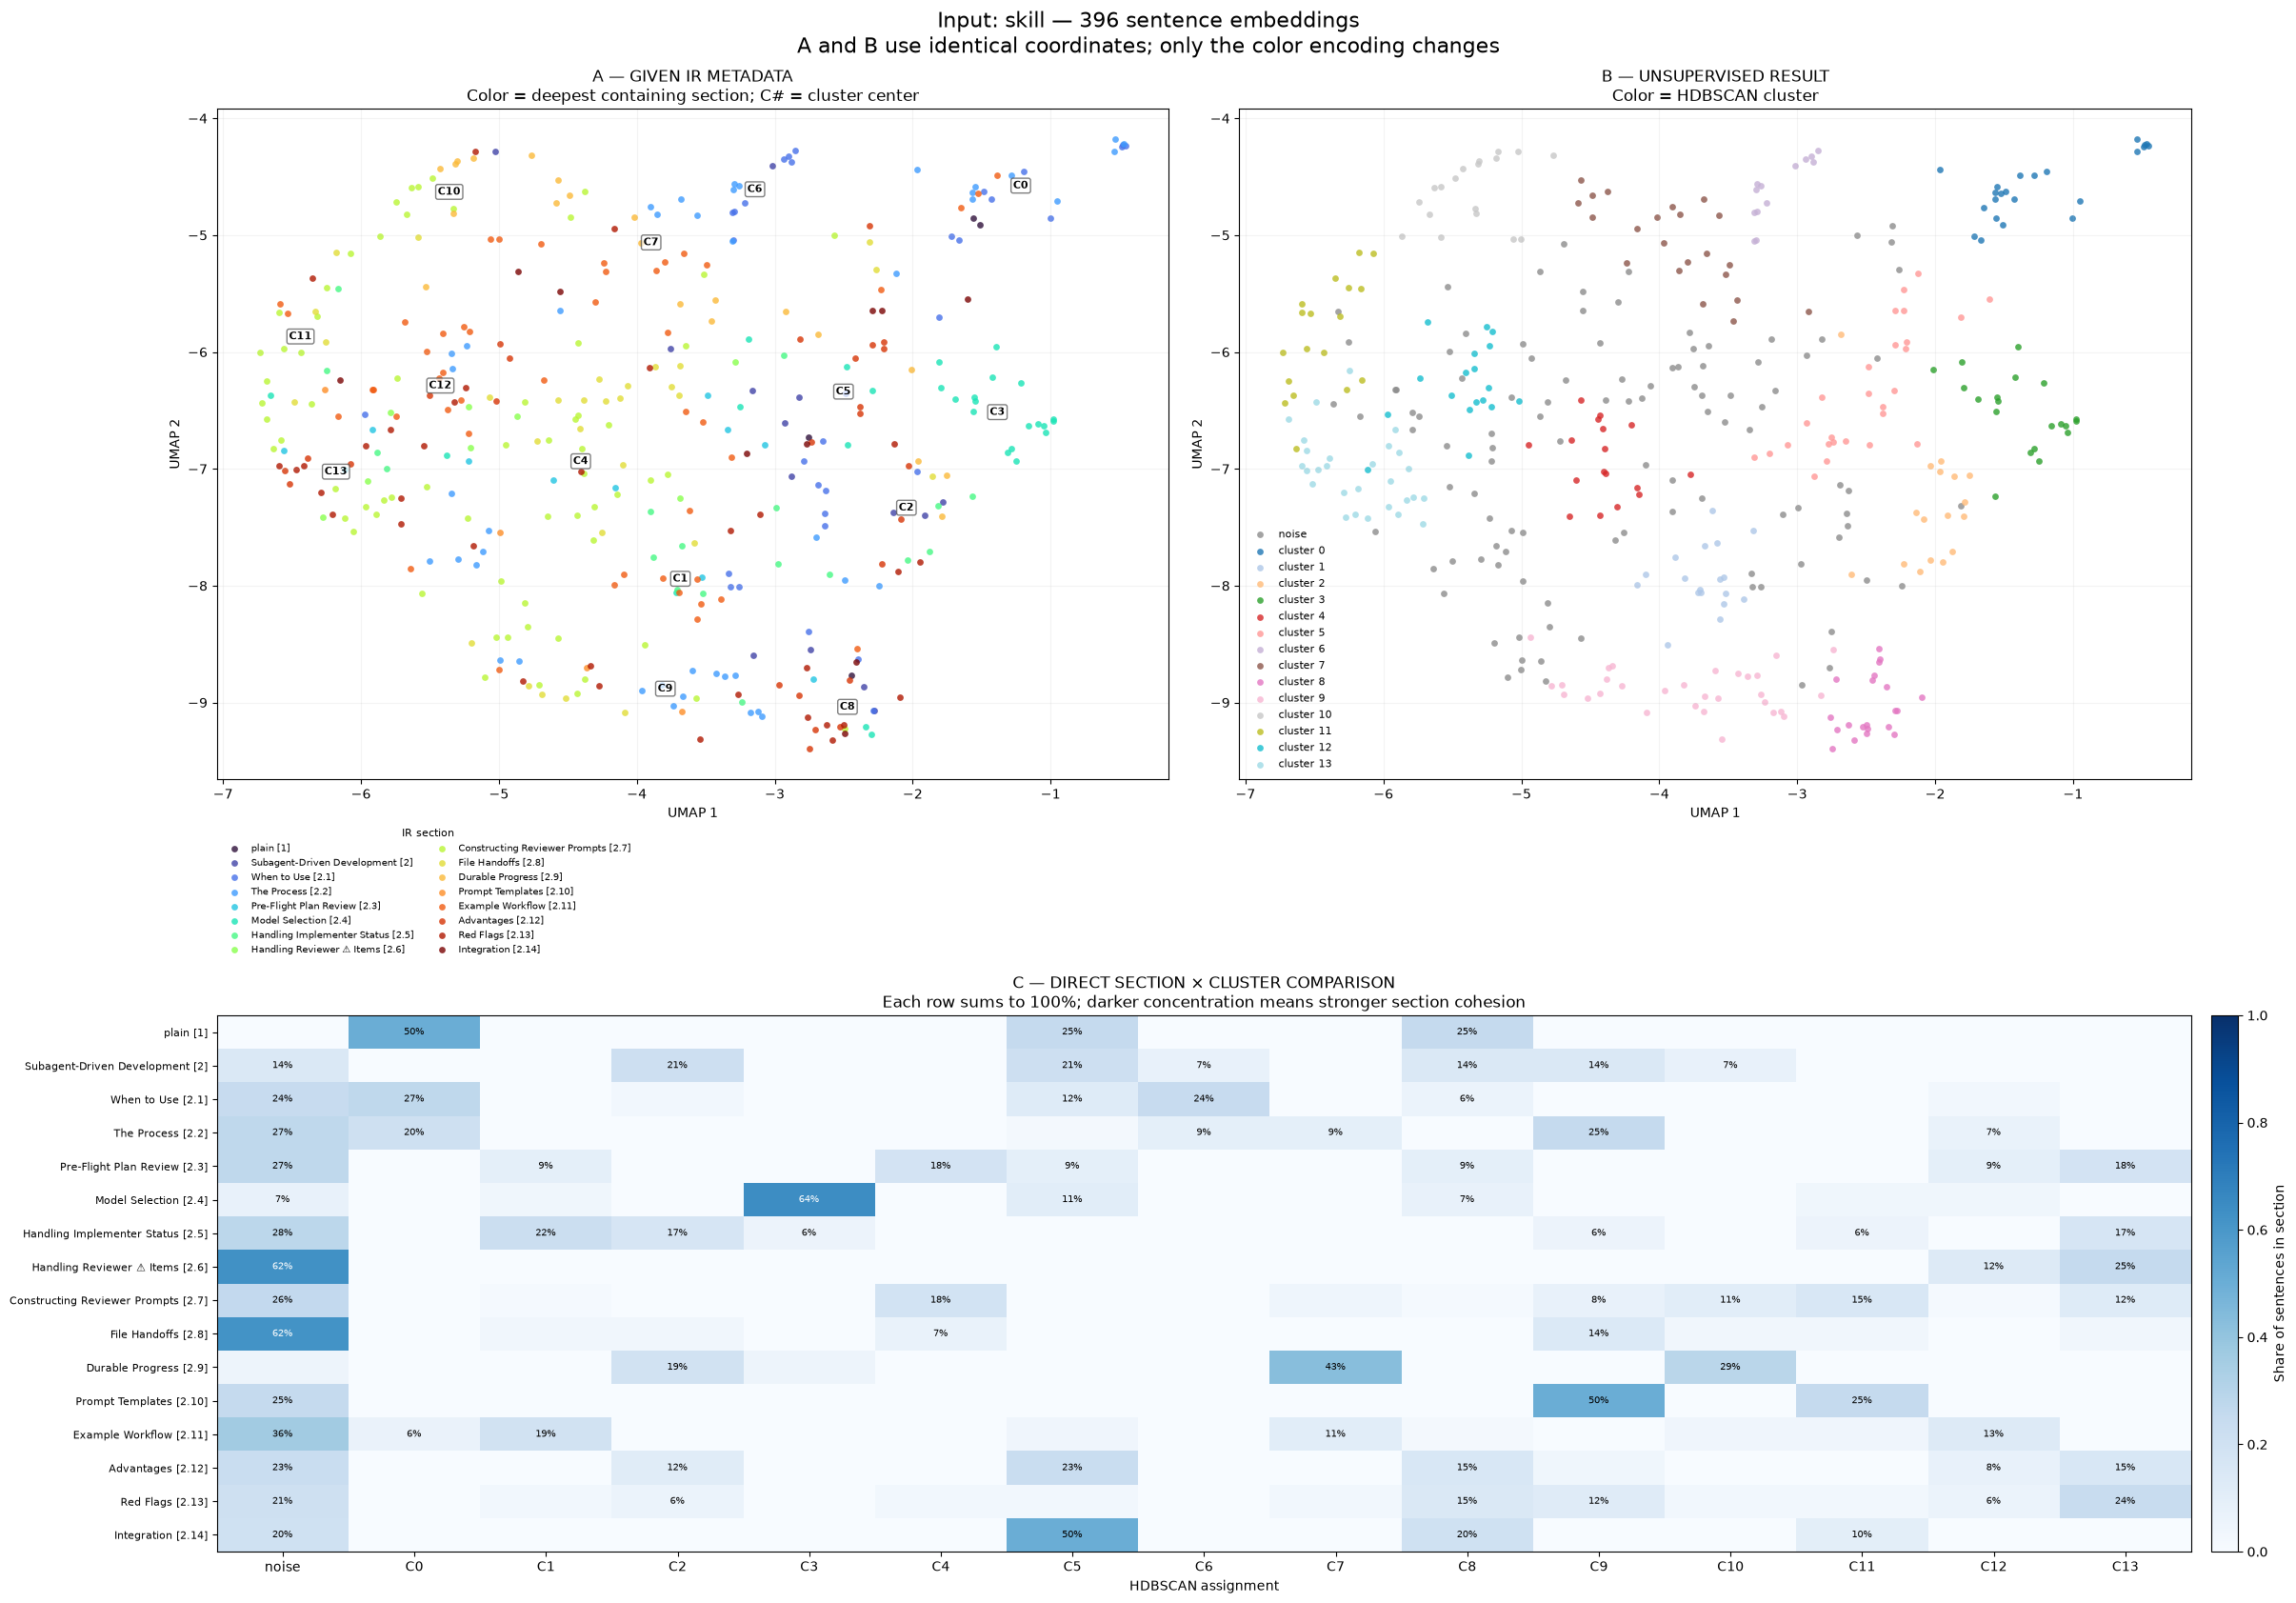

wrote notebooks/outputs/babilong_qa1_42_section_embedding_clusters.png


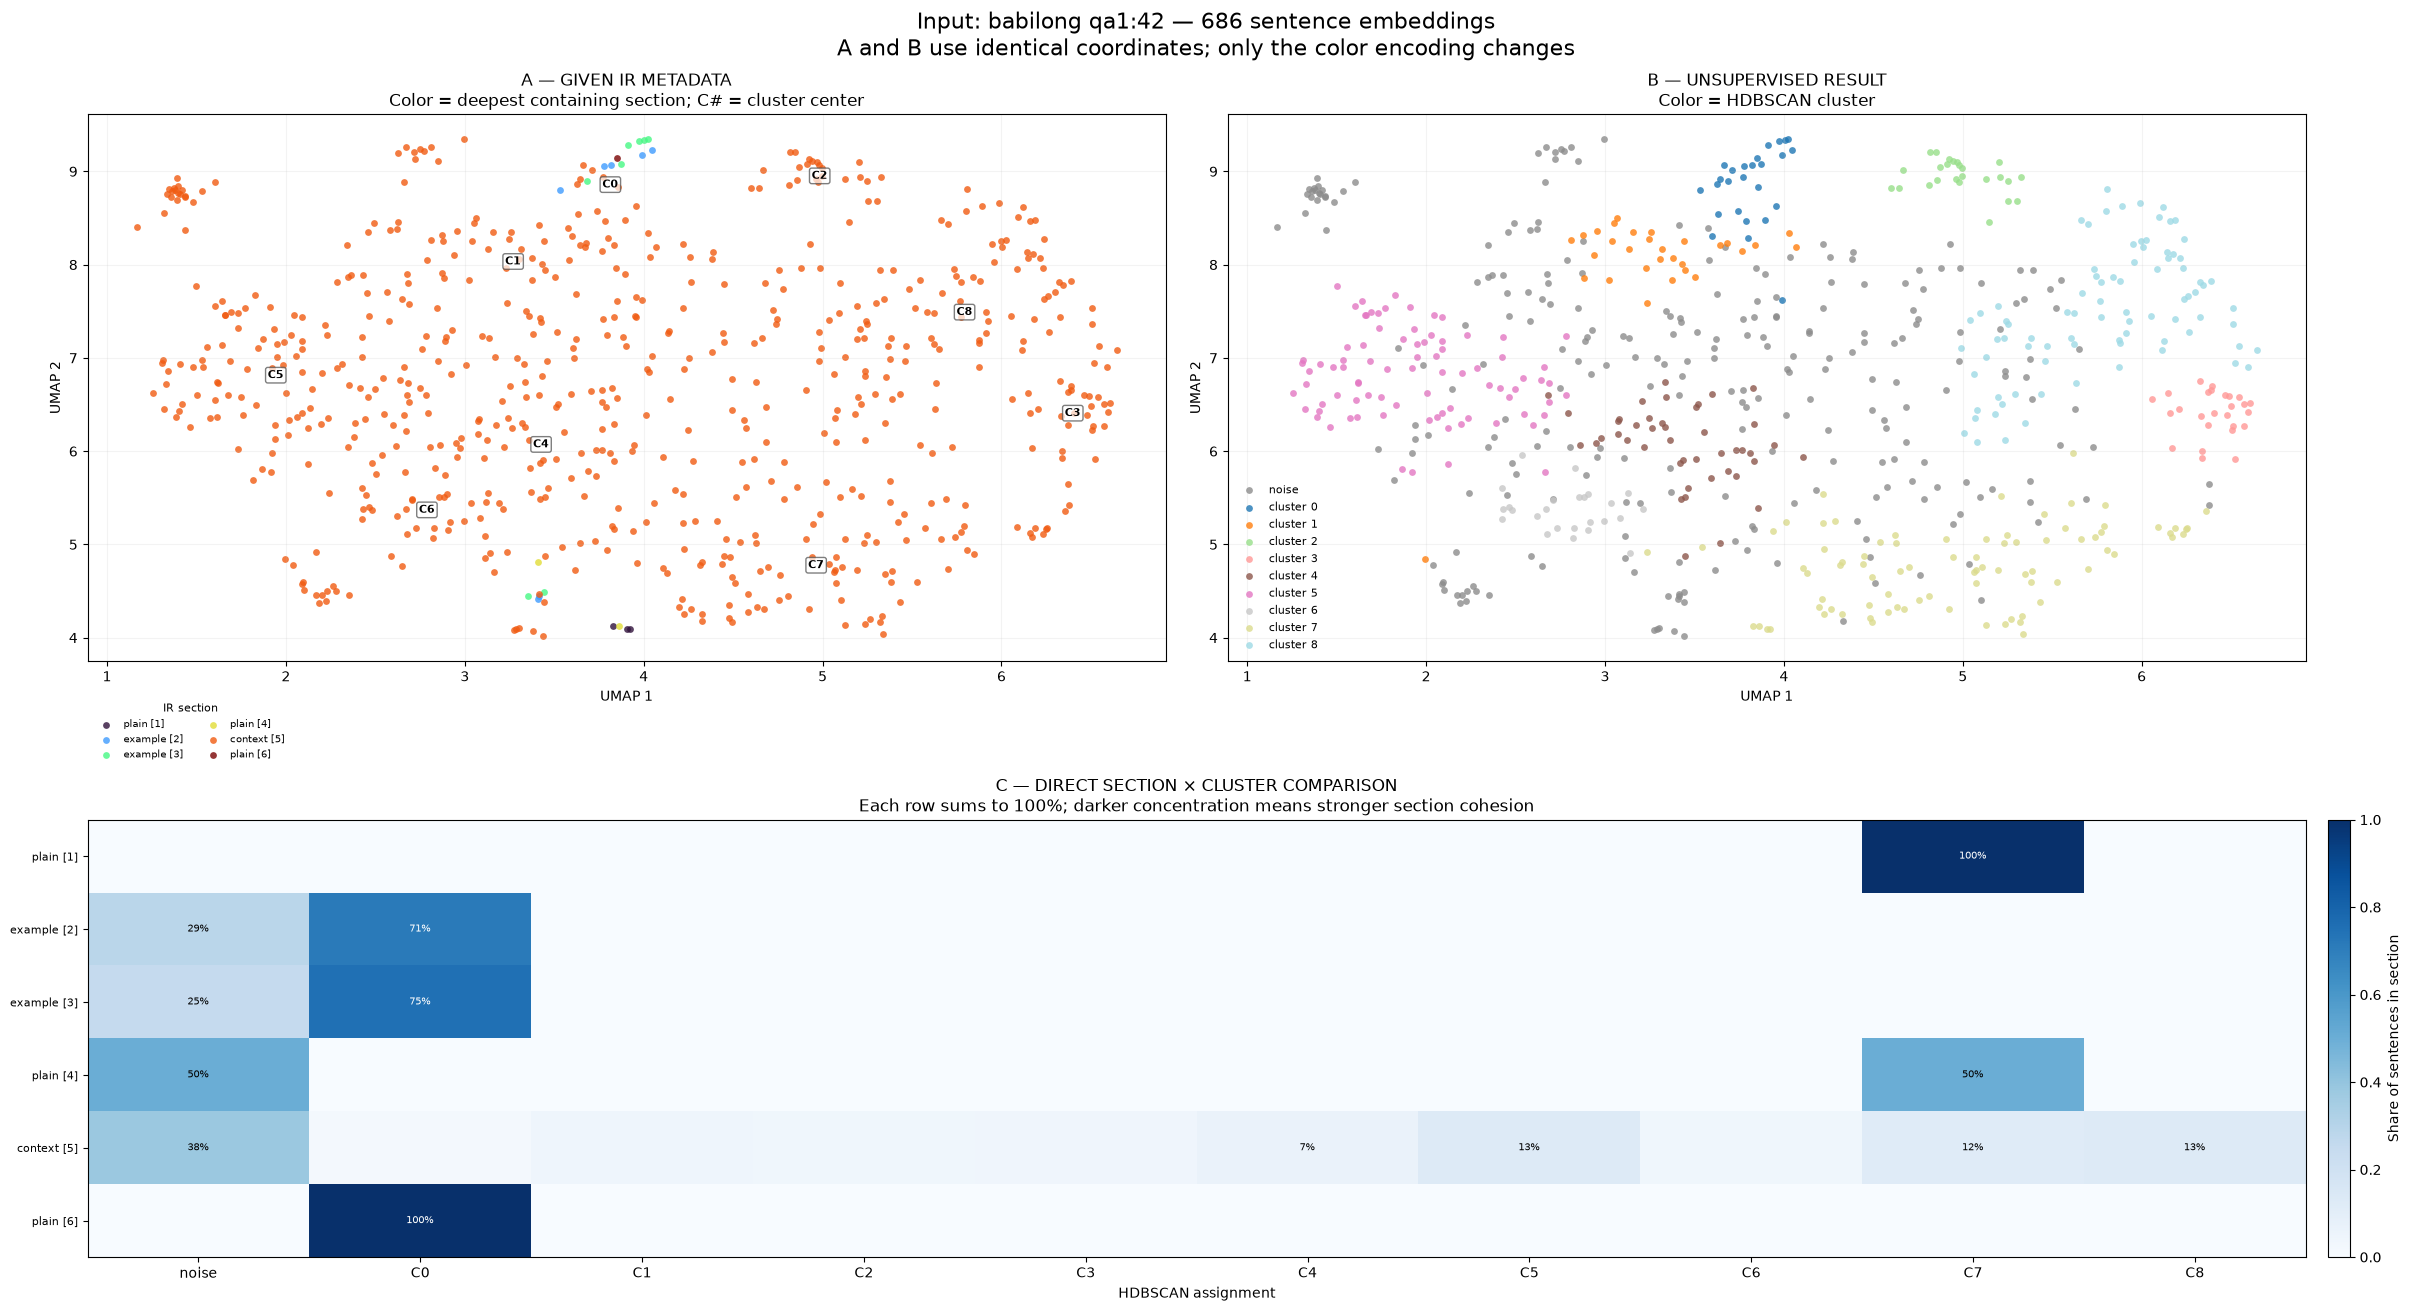

In [7]:
def plot_analysis(source: str, analysis: dict[str, object]) -> Path:
    source_rows = analysis["rows"]
    plot_space = analysis["plot_space"]
    cluster_labels = analysis["cluster_labels"]
    cluster_counts = analysis["cluster_counts"]
    section_counts = Counter(str(row["section"]) for row in source_rows)
    section_names = list(section_counts)
    section_cmap = plt.colormaps["turbo"].resampled(len(section_names))
    section_colors = {name: section_cmap(index) for index, name in enumerate(section_names)}
    cluster_ids = sorted(label for label in cluster_counts if label != -1)
    cluster_cmap = plt.colormaps["tab20"].resampled(max(1, len(cluster_ids)))
    cluster_colors = {label: cluster_cmap(index) for index, label in enumerate(cluster_ids)}
    cluster_colors[-1] = (0.55, 0.55, 0.55, 0.55)

    figure_height = max(13, 10 + 0.42 * len(section_names))
    fig = plt.figure(figsize=(24, figure_height), constrained_layout=True)
    grid = fig.add_gridspec(2, 2, height_ratios=(1.0, 0.8))
    axes = (fig.add_subplot(grid[0, 0]), fig.add_subplot(grid[0, 1]))
    heatmap_axis = fig.add_subplot(grid[1, :])

    for section_name in section_names:
        mask = np.array([row["section"] == section_name for row in source_rows])
        display_name = section_name.split(" / ", 1)[-1]
        axes[0].scatter(
            plot_space[mask, 0],
            plot_space[mask, 1],
            s=24,
            alpha=0.8,
            color=section_colors[section_name],
            label=display_name,
            linewidths=0,
        )
    for label in cluster_ids:
        center = plot_space[cluster_labels == label].mean(axis=0)
        axes[0].annotate(
            f"C{label}",
            center,
            ha="center",
            va="center",
            fontsize=8,
            fontweight="bold",
            bbox={"boxstyle": "round,pad=0.2", "fc": "white", "alpha": 0.72, "ec": "0.3"},
        )
    axes[0].set_title("A — GIVEN IR METADATA\nColor = deepest containing section; C# = cluster center")
    axes[0].legend(
        title="IR section",
        loc="upper left",
        bbox_to_anchor=(0, -0.06),
        fontsize=7,
        title_fontsize=8,
        ncol=2,
        frameon=False,
    )

    for label in sorted(cluster_counts):
        mask = cluster_labels == label
        axes[1].scatter(
            plot_space[mask, 0],
            plot_space[mask, 1],
            s=24,
            alpha=0.8,
            color=cluster_colors[label],
            label="noise" if label == -1 else f"cluster {label}",
            linewidths=0,
        )
    axes[1].set_title("B — UNSUPERVISED RESULT\nColor = HDBSCAN cluster")
    axes[1].legend(loc="best", fontsize=8, frameon=False)

    for axis in axes:
        axis.set_xlabel("UMAP 1")
        axis.set_ylabel("UMAP 2")
        axis.grid(alpha=0.15)

    heatmap_labels = ([-1] if -1 in cluster_counts else []) + cluster_ids
    section_cluster_share = np.zeros((len(section_names), len(heatmap_labels)))
    for section_index, section_name in enumerate(section_names):
        section_mask = np.array([row["section"] == section_name for row in source_rows])
        for cluster_index, label in enumerate(heatmap_labels):
            section_cluster_share[section_index, cluster_index] = np.mean(cluster_labels[section_mask] == label)
    heatmap = heatmap_axis.imshow(section_cluster_share, aspect="auto", cmap="Blues", vmin=0, vmax=1)
    heatmap_axis.set_xticks(
        range(len(heatmap_labels)),
        ["noise" if label == -1 else f"C{label}" for label in heatmap_labels],
    )
    display_sections = [name.split(" / ", 1)[-1] for name in section_names]
    heatmap_axis.set_yticks(range(len(section_names)), display_sections, fontsize=8)
    heatmap_axis.set_xlabel("HDBSCAN assignment")
    heatmap_axis.set_title(
        "C — DIRECT SECTION × CLUSTER COMPARISON\n"
        "Each row sums to 100%; darker concentration means stronger section cohesion"
    )
    for section_index in range(len(section_names)):
        for cluster_index in range(len(heatmap_labels)):
            share = section_cluster_share[section_index, cluster_index]
            if share >= 0.05:
                heatmap_axis.text(
                    cluster_index,
                    section_index,
                    f"{share:.0%}",
                    ha="center",
                    va="center",
                    fontsize=7,
                    color="white" if share >= 0.55 else "black",
                )
    colorbar = fig.colorbar(heatmap, ax=heatmap_axis, fraction=0.02, pad=0.01)
    colorbar.set_label("Share of sentences in section")

    fig.suptitle(
        f"Input: {source} — {len(source_rows):,} sentence embeddings\n"
        "A and B use identical coordinates; only the color encoding changes",
        fontsize=16,
    )
    slug = source.lower().replace(" ", "_").replace(":", "_")
    output_path = REPO_ROOT / f"notebooks/outputs/{slug}_section_embedding_clusters.png"
    output_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(output_path, dpi=180, bbox_inches="tight")
    print(f"wrote {output_path.relative_to(REPO_ROOT)}")
    plt.show()
    return output_path


output_paths = [plot_analysis(source, analyses[source]) for source in inputs]